<a href="https://colab.research.google.com/github/TAUforPython/TMS-pain-analysis/blob/main/ML_TMS_pain_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
link_url = 'https://raw.githubusercontent.com/TAUforPython/TMS-pain-analysis/refs/heads/main/test_datasets/pain_score_linear_model.csv'

raw_data = pd.read_csv(link_url, sep = ';')
raw_data.head(5)

,patient_id,sex,age,pain_type,illnes_month,score_pain_reiting,score_osvestri,score_dn4,score_paint_detect,score_beck,...,motor_evoked_left,theshold_edge_right,theshold_edge_left,interstimul_threshod,inhibition_threshold_right,avg_avg_respone_right,avg_avg_respone_left,avg_interstimul_threshod,avg_inhibition_threshold_right,avg_inhibition_threshold_left
0,patient_ 1,0,72,1.0,324.0,9.0,58.0,5.0,24.0,24.0,...,"0,594",61,58,61,58,"140,7675","178,1633333",61,58,"3,277777778"
1,patient_ 2,1,60,0.0,120.0,NaN,NaN,NaN,NaN,NaN,...,"1,53",46,40,46,40,"73,48533333","51,33366667",46,40,"3,277777778"
2,patient_ 3,0,54,0.0,312.0,7.0,38.0,7.0,24.0,9.0,...,"1,07",56,60,56,60,"145,275","189,0625",56,60,"3,277777778"
3,patient_ 4,0,25,0.0,60.0,5.0,22.0,2.0,7.0,8.0,...,"1,4",26,33,26,33,"66,66191667","88,53916667",26,33,"3,277777778"
4,patient_ 5,0,42,0.0,24.0,8.0,48.0,3.0,7.0,22.0,...,"1,99",42,52,42,52,"59,29183333","59,76133333",42,52,"3,277777778"


In [11]:
raw_data.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
sex,47.0,0.30,0.46,0.0,0.00,0.0,1.00,1.0
age,47.0,54.36,15.11,20.0,43.00,59.0,66.00,78.0
pain_type,34.0,0.29,0.46,0.0,0.00,0.0,1.00,1.0
illnes_month,33.0,178.27,137.56,3.0,96.00,120.0,240.00,540.0
score_pain_reiting,30.0,6.13,1.96,2.0,5.00,6.0,8.00,10.0
score_osvestri,30.0,36.20,15.83,10.0,28.00,36.0,47.50,72.0
score_dn4,30.0,3.30,1.86,0.0,2.00,3.0,5.00,7.0
score_paint_detect,30.0,12.03,7.12,0.0,6.25,11.5,16.75,25.0
score_beck,28.0,13.64,7.15,2.0,8.75,13.0,18.25,27.0
score_spilberg_person,30.0,48.17,8.94,27.0,43.50,50.0,54.75,64.0


In [12]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 45 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   patient_id                      47 non-null     object 
 1   sex                             47 non-null     int64  
 2   age                             47 non-null     int64  
 3   pain_type                       34 non-null     float64
 4   illnes_month                    33 non-null     float64
 5   score_pain_reiting              30 non-null     float64
 6   score_osvestri                  30 non-null     float64
 7   score_dn4                       30 non-null     float64
 8   score_paint_detect              30 non-null     float64
 9   score_beck                      28 non-null     float64
 10  score_spilberg_person           30 non-null     float64
 11  score_spilberg_anxiety          30 non-null     float64
 12  score_pittsburg                 30 non

# Short review of three subset

In [13]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 45 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   patient_id                      47 non-null     object 
 1   sex                             47 non-null     int64  
 2   age                             47 non-null     int64  
 3   pain_type                       34 non-null     float64
 4   illnes_month                    33 non-null     float64
 5   score_pain_reiting              30 non-null     float64
 6   score_osvestri                  30 non-null     float64
 7   score_dn4                       30 non-null     float64
 8   score_paint_detect              30 non-null     float64
 9   score_beck                      28 non-null     float64
 10  score_spilberg_person           30 non-null     float64
 11  score_spilberg_anxiety          30 non-null     float64
 12  score_pittsburg                 30 non

In [14]:
table_data = raw_data
table_data.columns

Index(['patient_id', 'sex', 'age', 'pain_type', 'illnes_month',
       'score_pain_reiting', 'score_osvestri', 'score_dn4',
       'score_paint_detect', 'score_beck', 'score_spilberg_person',
       'score_spilberg_anxiety', 'score_pittsburg', 'score_csi',
       'restless_legs', 'fatigue', 'fibrimyalgia', 'tmdibular_pathology',
       'migraine', 'bowel_irritable ', 'chemy_sensitive', 'neck_injuries',
       'panic_attack', 'depression', 'score_mak_gill', 'nsaid_drug',
       'miorelax_drug', 'antidepress_drug', 'anticonv_drug',
       'radio_freq_denerv', 'exercise_therapy', 'therapy_blockade',
       'threshold_left', 'threshold_right', 'motor_evoked_right',
       'motor_evoked_left', 'theshold_edge_right', 'theshold_edge_left',
       'interstimul_threshod', 'inhibition_threshold_right',
       'avg_avg_respone_right', 'avg_avg_respone_left',
       'avg_interstimul_threshod', 'avg_inhibition_threshold_right',
       'avg_inhibition_threshold_left'],
      dtype='object')

In [15]:
subset_patient_columns = [
    'patient_id', 'sex', 'age', 'pain_type', 'illnes_month'
    ]

subset_score_columns = [
    'patient_id',
    'score_pain_reiting', 'score_osvestri', 'score_dn4',
    'score_paint_detect', 'score_beck', 'score_spilberg_person',
    'score_spilberg_anxiety', 'score_pittsburg', 'score_csi','score_mak_gill'
    ]

subset_dignosis_columns = [
    'patient_id',
    'restless_legs', 'fatigue', 'fibrimyalgia', 'tmdibular_pathology',
    'migraine', 'bowel_irritable ', 'chemy_sensitive', 'neck_injuries',
    'panic_attack', 'depression'
    ]

subset_therapy_columns = [
    'patient_id',
    'nsaid_drug',
    'miorelax_drug', 'antidepress_drug', 'anticonv_drug',
    'radio_freq_denerv', 'exercise_therapy', 'therapy_blockade'
    ]

subset_tms_columns = [
    'patient_id',
    'threshold_left', 'threshold_right', 'motor_evoked_right','motor_evoked_left', 'theshold_edge_right', 'theshold_edge_left',
    'interstimul_threshod', 'inhibition_threshold_right',
    'avg_avg_respone_right', 'avg_avg_respone_left',
    'avg_interstimul_threshod', 'avg_inhibition_threshold_right',
    'avg_inhibition_threshold_left'
    ]

# Helicopter view
Perform a comprehensive exploratory data analysis and visualization on the DataFrame `table_data`.  This analysis include: data cleaning; visualizing patient demographics and basic information through histograms for 'age' and 'illnes_month', and countplots for 'sex' and 'pain_type'; generating a correlation heatmap for patient score metrics; creating countplots to show diagnosis and treatment prevalence; and finally, visualizing the relationships between Transcranial Magnetic Stimulation (TMS) measurements with another correlation heatmap.

## Stat analysis

In [16]:
table_data = raw_data

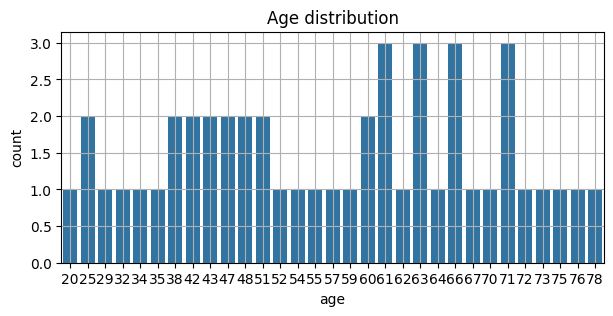

In [17]:
plt.figure(figsize=(7,3))
sns.countplot(data=table_data, x='age')
plt.title('Age distribution')
plt.grid()
plt.show()

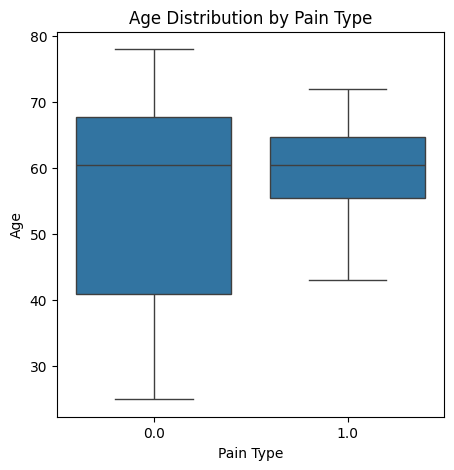

In [18]:
plt.figure(figsize=(5, 5))
sns.boxplot(data=table_data, x='pain_type', y='age')
plt.title('Age Distribution by Pain Type')
plt.xlabel('Pain Type')
plt.ylabel('Age')
plt.show()

In [19]:
for col in table_data.columns:
    if col != 'patient_id': # Exclude 'patient_id' from conversion
        # Ensure the column is treated as string before replacement to avoid errors on mixed types
        table_data[col] = table_data[col].astype(str).str.replace(',', '.', regex=False)
        # Convert to numeric, coercing errors to NaN
        table_data[col] = pd.to_numeric(table_data[col], errors='coerce')

        # Impute missing values with the mean if any NaNs are present after conversion
        #if table_data[col].isnull().any():
        #    table_data[col] = table_data[col].fillna(table_data[col].mean())

print("table_data DataFrame has been cleaned: columns converted to numeric, comma decimals handled, and missing values imputed with the mean.")
print(table_data.head())

table_data DataFrame has been cleaned: columns converted to numeric, comma decimals handled, and missing values imputed with the mean.
   patient_id  sex  age  pain_type  illnes_month  score_pain_reiting  \
0  patient_ 1    0   72        1.0         324.0                 9.0   
1  patient_ 2    1   60        0.0         120.0                 NaN   
2  patient_ 3    0   54        0.0         312.0                 7.0   
3  patient_ 4    0   25        0.0          60.0                 5.0   
4  patient_ 5    0   42        0.0          24.0                 8.0   

   score_osvestri  score_dn4  score_paint_detect  score_beck  ...  \
0            58.0        5.0                24.0        24.0  ...   
1             NaN        NaN                 NaN         NaN  ...   
2            38.0        7.0                24.0         9.0  ...   
3            22.0        2.0                 7.0         8.0  ...   
4            48.0        3.0                 7.0        22.0  ...   

   motor_evoked_l

## Visualize Patient Demographics and Basic Information

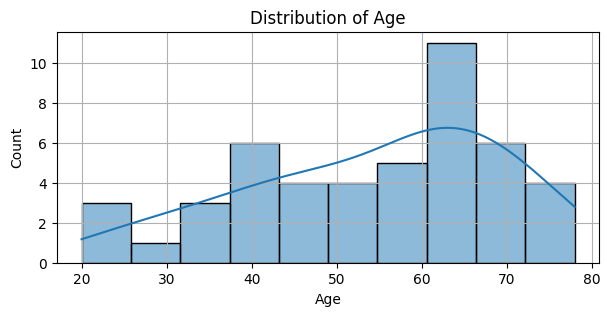

In [20]:
plt.figure(figsize=(7, 3))
sns.histplot(data=table_data, x='age', kde=True, bins=10)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(True)
plt.show()

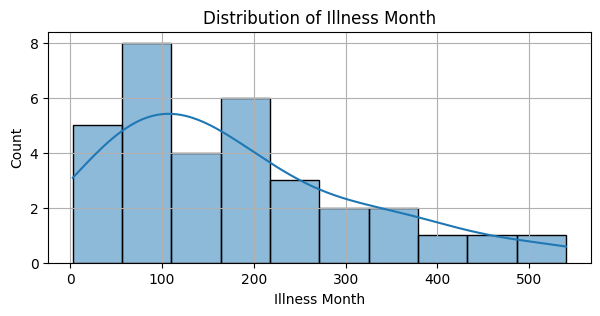

In [21]:
plt.figure(figsize=(7, 3))
sns.histplot(data=table_data, x='illnes_month', kde=True, bins=10)
plt.title('Distribution of Illness Month')
plt.xlabel('Illness Month')
plt.ylabel('Count')
plt.grid(True)
plt.show()

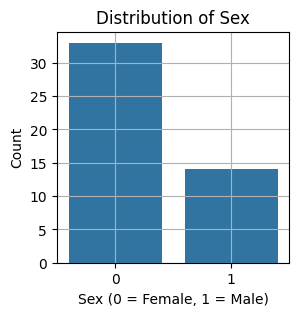

In [22]:
plt.figure(figsize=(3, 3))
sns.countplot(data=table_data, x='sex')
plt.title('Distribution of Sex')
plt.xlabel('Sex (0 = Female, 1 = Male)')
plt.ylabel('Count')
plt.grid(True)
plt.show()

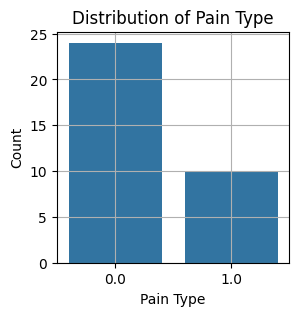

In [23]:
plt.figure(figsize=(3, 3))
sns.countplot(data=table_data[['patient_id','pain_type']].dropna(), x='pain_type')
plt.title('Distribution of Pain Type')
plt.xlabel('Pain Type')
plt.ylabel('Count')
plt.grid(True)
plt.show()

## Visualize Patient Scores Correlation Heatmap


Generate a correlation heatmap for the 'subset_score_columns' (excluding 'patient_id'). This display the Pearson correlation coefficients between the various patient score metrics, highlighting their interrelationships.


Score data prepared for correlation analysis.


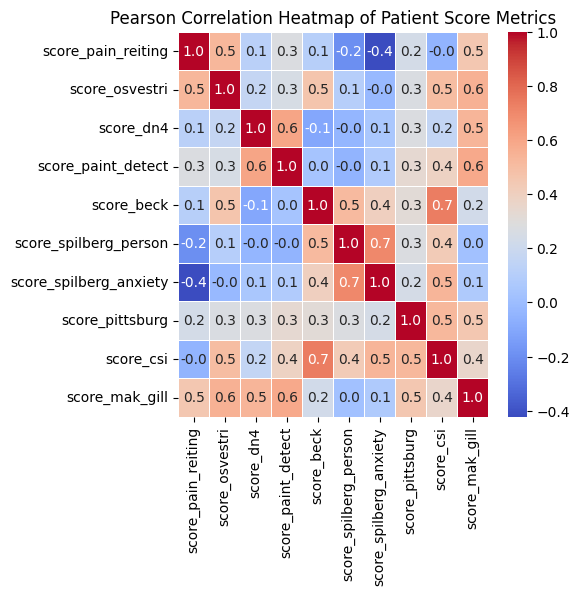

In [24]:
score_data = table_data[subset_score_columns].drop('patient_id', axis=1)

print("Score data prepared for correlation analysis.")

correlation_matrix_scores = score_data.corr()

plt.figure(figsize=(5, 5))
sns.heatmap(correlation_matrix_scores, annot=True, cmap='coolwarm', fmt=".1f", linewidths=.5)
plt.title('Pearson Correlation Heatmap of Patient Score Metrics')
plt.show()

## Visualize Diagnosis and Treatment data


In [25]:
diagnosis_data = table_data[subset_dignosis_columns].drop('patient_id', axis=1)
diagnosis_data = diagnosis_data.drop('tmdibular_pathology', axis=1)

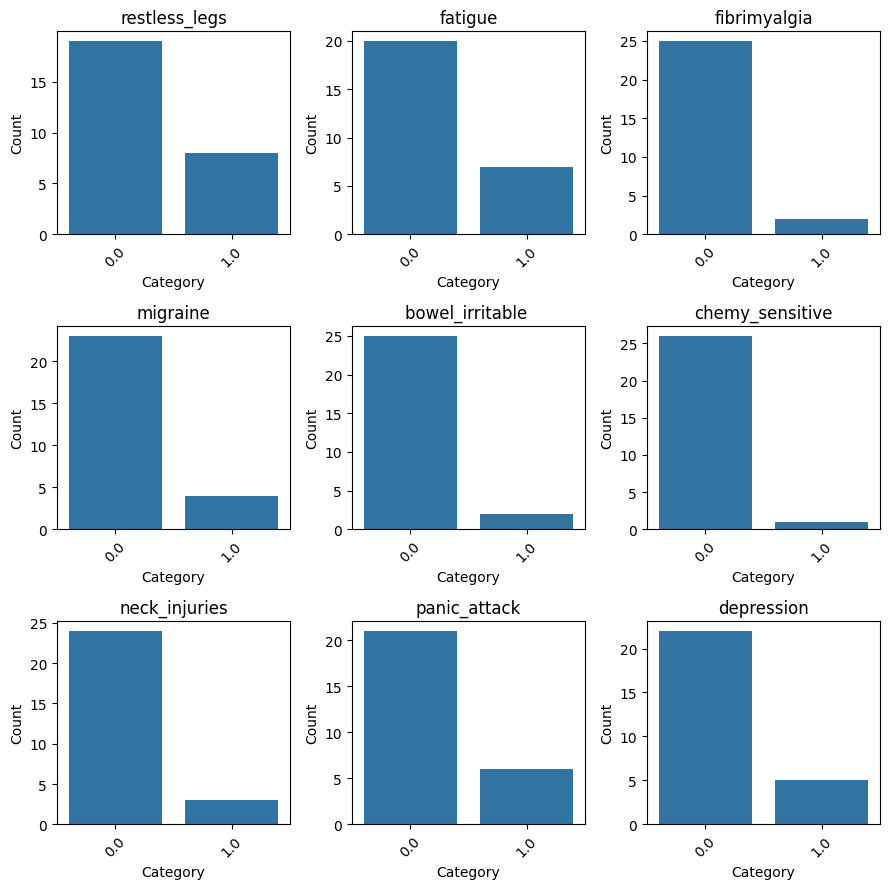

Countplots for diagnosis and treatment features generated.


In [26]:
import math

num_features = diagnosis_data.shape[1]
ncols = 3
nrows = math.ceil(num_features / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3 * ncols, 3 * nrows))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(diagnosis_data.columns):
    sns.countplot(data=diagnosis_data, x=col, ax=axes[i])
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('Category')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

print("Countplots for diagnosis and treatment features generated.")

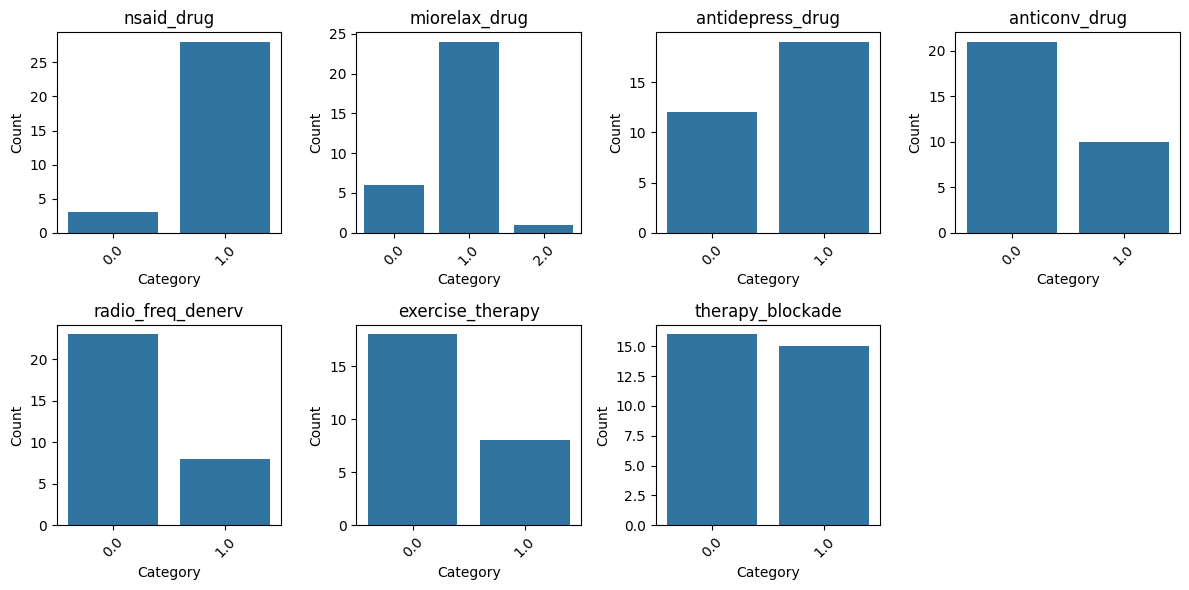

In [27]:
therapy_data = table_data[subset_therapy_columns].drop('patient_id', axis=1)

num_features = therapy_data.shape[1]
ncols = 4
nrows = math.ceil(num_features / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3 * ncols, 3 * nrows))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(therapy_data.columns):
    sns.countplot(data=therapy_data, x=col, ax=axes[i])
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('Category')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## Score clustering
Prepare the patient score data by creating a DataFrame from `table_data` using `patient_id` and the columns in `subset_score_columns`. Then, prepare the  patients with complete score data for K-Means clustering by dropping `patient_id`. Normalize this complete score data using `StandardScaler` to ensure all features contribute equally to the clustering process.

In [28]:
score_data_with_id = table_data[subset_score_columns]

nan_patients = score_data_with_id[score_data_with_id.drop('patient_id', axis=1).isnull().any(axis=1)].copy()
clean_patients = score_data_with_id.dropna(subset=score_data_with_id.drop('patient_id', axis=1).columns).copy()

# Assign 'NaN_Cluster' to patients with missing values
nan_patients['cluster'] = 'NaN_Cluster'

# Prepare clean data for clustering by dropping 'patient_id'
df_clustering_scores = clean_patients.drop('patient_id', axis=1)

print(f"Patients with missing values (NaN_Cluster): {len(nan_patients)}")
print(f"Patients with complete score data for clustering: {len(clean_patients)}")
#print("First 5 rows of df_clustering_scores (clean data for clustering):")
#print(df_clustering_scores.head())

Patients with missing values (NaN_Cluster): 24
Patients with complete score data for clustering: 23


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled_scores = pd.DataFrame(scaler.fit_transform(df_clustering_scores), columns=df_clustering_scores.columns)


To group patients based on their scores, apply the K-Means clustering algorithm to the scaled data, as specified in the instructions. This involves instantiating KMeans, fitting it to the `df_scaled_scores` DataFrame, and extracting the cluster labels.



In [30]:
from sklearn.cluster import KMeans

n_clusters = 3
kmeans_scores = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

# Fit the KMeans model to the scaled score data
kmeans_scores.fit(df_scaled_scores)

# Get cluster labels
cluster_labels_scores = kmeans_scores.labels_

print(f"KMeans clustering performed with {n_clusters} clusters on score data.")
print(f"First 5 cluster labels: {cluster_labels_scores[:5]}")

KMeans clustering performed with 3 clusters on score data.
First 5 cluster labels: [2 0 1 1 0]


In [31]:
clean_patients['cluster'] = cluster_labels_scores

all_patients_clustered = pd.concat([clean_patients, nan_patients], ignore_index=True)

all_patients_clustered = all_patients_clustered.rename(columns={'cluster': 'Score_cluster'})

print("Column 'cluster' renamed to 'Score_cluster'.")
print(all_patients_clustered[['patient_id', 'Score_cluster']].head())

Column 'cluster' renamed to 'Score_cluster'.
    patient_id Score_cluster
0   patient_ 1             2
1   patient_ 7             0
2   patient_ 8             1
3  patient_ 20             1
4  patient_ 21             0


In [32]:
print("Distribution of patients across Score_clusters:")
print(all_patients_clustered['Score_cluster'].value_counts())

Distribution of patients across Score_clusters:
Score_cluster
NaN_Cluster    24
2               9
1               8
0               6
Name: count, dtype: int64



*   K-Means clustering was performed on the normalized score data, identifying **3 distinct clusters** (Cluster 0, 1, and 2).
*   The final distribution of patients across the clusters is:
    *   **NaN_Cluster**: 23 patients
    *   **Cluster 2**: 9 patients
    *   **Cluster 1**: 8 patients
    *   **Cluster 0**: 6 patients
*   Approximately **51%** (24 out of 45) of the patients had missing score data, necessitating their exclusion from the K-Means analysis.

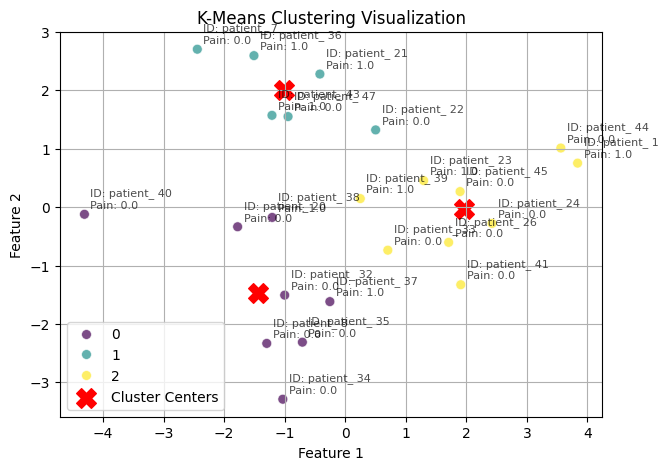

In [34]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2) # Or 3 for 3D visualization
principal_components = pca.fit_transform(df_scaled_scores)
pca_score_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

kmeans = KMeans(n_clusters=3, random_state=0, n_init=10) # n_init for robust initialization

kmeans.fit(np.array(pca_score_df))
labels = kmeans.predict(np.array(pca_score_df))
cluster_centers = kmeans.cluster_centers_

# Add patient_id and pain_type to pca_score_df for annotation
pca_score_df['patient_id'] = clean_patients['patient_id'].values
pca_score_df['cluster_label'] = labels
# Merge pain_type from the original table_data
pca_score_df = pd.merge(pca_score_df, table_data[['patient_id', 'pain_type']], on='patient_id', how='left')


# 3. Create the Scatter Plot
plt.figure(figsize=(7, 5))

# Plot data points, colored by cluster label
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='cluster_label',
    palette='viridis',
    data=pca_score_df,
    legend='full',
    s=50,
    alpha=0.7
)

# Plot cluster centers
plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], c='red', s=200, marker='X', label='Cluster Centers')


# Add labels for patient_id and pain_type
for i, row in pca_score_df.iterrows():
    plt.text(row['PC1'] + 0.1, row['PC2'] + 0.1,
             f"ID: {row['patient_id']}\nPain: {row['pain_type']}", # Display patient_id and pain_type
             fontsize=8, alpha=0.7)

# 4. Add Labels and Title
plt.title('K-Means Clustering Visualization')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

In [35]:
pca.explained_variance_ratio_

array([0.36600695, 0.24834564])

#Case 1: Linear Regression model classification

In [54]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import silhouette_score, classification_report, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.manifold import TSNE
from sklearn.svm import LinearSVC
from mpl_toolkits import mplot3d
from tqdm import tqdm

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

In [55]:
table_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 45 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   patient_id                      47 non-null     object 
 1   sex                             47 non-null     int64  
 2   age                             47 non-null     int64  
 3   pain_type                       34 non-null     float64
 4   illnes_month                    33 non-null     float64
 5   score_pain_reiting              30 non-null     float64
 6   score_osvestri                  30 non-null     float64
 7   score_dn4                       30 non-null     float64
 8   score_paint_detect              30 non-null     float64
 9   score_beck                      28 non-null     float64
 10  score_spilberg_person           30 non-null     float64
 11  score_spilberg_anxiety          30 non-null     float64
 12  score_pittsburg                 30 non

In [56]:
table_data_linear_model = table_data.dropna()
table_data_linear_model = table_data_linear_model.drop('patient_id', axis=1)
table_data_linear_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19 entries, 0 to 44
Data columns (total 44 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   sex                             19 non-null     int64  
 1   age                             19 non-null     int64  
 2   pain_type                       19 non-null     float64
 3   illnes_month                    19 non-null     float64
 4   score_pain_reiting              19 non-null     float64
 5   score_osvestri                  19 non-null     float64
 6   score_dn4                       19 non-null     float64
 7   score_paint_detect              19 non-null     float64
 8   score_beck                      19 non-null     float64
 9   score_spilberg_person           19 non-null     float64
 10  score_spilberg_anxiety          19 non-null     float64
 11  score_pittsburg                 19 non-null     float64
 12  score_csi                       19 non-null

In [60]:
X_clf = table_data_linear_model.drop('pain_type', axis=1)
y_clf = table_data_linear_model['pain_type']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

scaler_c = StandardScaler()
X_train_csc = scaler_c.fit_transform(X_train_c)
X_test_csc  = scaler_c.transform(X_test_c)

print(f"Train: {X_train_c.shape}  |  Test: {X_test_c.shape}")
print(f"Доля дефолтов в train: {y_train_c.mean():.2%}")
print(f"Доля дефолтов в test:  {y_test_c.mean():.2%}")

Train: (15, 43)  |  Test: (4, 43)
Доля дефолтов в train: 40.00%
Доля дефолтов в test:  25.00%


In [58]:
# Logistic Regression
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_csc, y_train_c)

y_pred_log = log_reg.predict(X_test_csc)
y_proba_log = log_reg.predict_proba(X_test_csc)[:, 1]

log_acc = accuracy_score(y_test_c, y_pred_log)
log_prec = precision_score(y_test_c, y_pred_log)
log_rec = recall_score(y_test_c, y_pred_log)
log_f1 = f1_score(y_test_c, y_pred_log)
log_auc = roc_auc_score(y_test_c, y_proba_log)

print("Logistic Regression")
print(f"  Accuracy  = {log_acc:.4f}")
print(f"  Precision = {log_prec:.4f}")
print(f"  Recall    = {log_rec:.4f}")
print(f"  F1-Score  = {log_f1:.4f}")
print(f"  ROC-AUC   = {log_auc:.4f}")

# Коэффициенты
coef_log = pd.DataFrame({
    'feature': X_clf.columns,
    'odds_ratio': np.exp(log_reg.coef_[0])
}).sort_values('odds_ratio', ascending=False)
print("\nОтношение шансов (odds ratio):")
print(coef_log.to_string(index=False))

Logistic Regression
  Accuracy  = 0.5000
  Precision = 0.0000
  Recall    = 0.0000
  F1-Score  = 0.0000
  ROC-AUC   = 0.6667

Отношение шансов (odds ratio):
                       feature  odds_ratio
                     score_dn4    2.242750
                 anticonv_drug    1.791840
         avg_avg_respone_right    1.470746
            score_paint_detect    1.350074
         score_spilberg_person    1.325875
                       fatigue    1.313406
                score_mak_gill    1.292390
                    nsaid_drug    1.279861
                  fibrimyalgia    1.267353
                           age    1.258052
              antidepress_drug    1.251198
                    depression    1.200553
    inhibition_threshold_right    1.079289
avg_inhibition_threshold_right    1.079289
            theshold_edge_left    1.079289
        score_spilberg_anxiety    1.076830
             radio_freq_denerv    1.069294
               threshold_right    1.053808
                score_osve

In [64]:
# Decision Tree Classifier
dt_clf = DecisionTreeClassifier(random_state=42, max_depth=8)
dt_clf.fit(X_train_csc, y_train_c)

y_pred_dt_c  = dt_clf.predict(X_test_csc)
y_proba_dt_c = dt_clf.predict_proba(X_test_csc)[:, 1]

dt_c_acc  = accuracy_score(y_test_c, y_pred_dt_c)
dt_c_prec = precision_score(y_test_c, y_pred_dt_c)
dt_c_rec  = recall_score(y_test_c, y_pred_dt_c)
dt_c_f1   = f1_score(y_test_c, y_pred_dt_c)
dt_c_auc  = roc_auc_score(y_test_c, y_proba_dt_c)

dt_c_train_acc = accuracy_score(y_train_c, dt_clf.predict(X_train_csc))

print("Decision Tree (max_depth=8)")
print(f"  Train Accuracy = {dt_c_train_acc:.4f}")
print(f"  Test  Accuracy = {dt_c_acc:.4f}")
print(f"  Precision      = {dt_c_prec:.4f}")
print(f"  Recall         = {dt_c_rec:.4f}")
print(f"  F1-Score       = {dt_c_f1:.4f}")
print(f"  ROC-AUC        = {dt_c_auc:.4f}")

if dt_c_train_acc - dt_c_acc > 0.05:
    print(" Возможно переобучение (Train >> Test)")

plt.figure(figsize=(8,4))

Decision Tree (max_depth=8)
  Train Accuracy = 1.0000
  Test  Accuracy = 0.7500
  Precision      = 0.5000
  Recall         = 1.0000
  F1-Score       = 0.6667
  ROC-AUC        = 0.8333
 Возможно переобучение (Train >> Test)


<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Random Forest (100 деревьев, max_depth=10)
  Accuracy  = 0.7500
  Precision = 0.0000
  Recall    = 0.0000
  F1-Score  = 0.0000
  ROC-AUC   = 0.6667


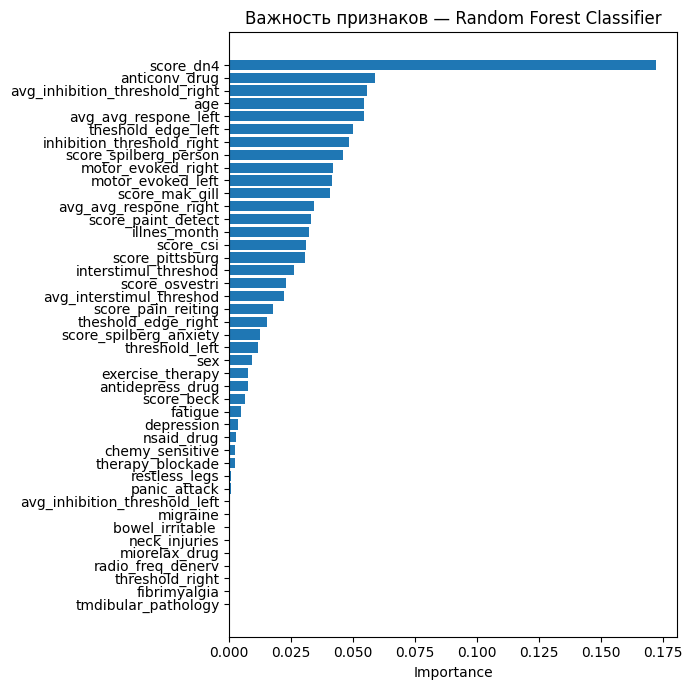

In [67]:
# Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_clf.fit(X_train_csc, y_train_c)

y_pred_rf_c  = rf_clf.predict(X_test_csc)
y_proba_rf_c = rf_clf.predict_proba(X_test_csc)[:, 1]

rf_c_acc  = accuracy_score(y_test_c, y_pred_rf_c)
rf_c_prec = precision_score(y_test_c, y_pred_rf_c)
rf_c_rec  = recall_score(y_test_c, y_pred_rf_c)
rf_c_f1   = f1_score(y_test_c, y_pred_rf_c)
rf_c_auc  = roc_auc_score(y_test_c, y_proba_rf_c)

print("Random Forest (100 деревьев, max_depth=10)")
print(f"  Accuracy  = {rf_c_acc:.4f}")
print(f"  Precision = {rf_c_prec:.4f}")
print(f"  Recall    = {rf_c_rec:.4f}")
print(f"  F1-Score  = {rf_c_f1:.4f}")
print(f"  ROC-AUC   = {rf_c_auc:.4f}")

# Важность признаков
feat_imp_clf = pd.DataFrame({
    'feature': X_clf.columns,
    'importance': rf_clf.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(7, 7))
plt.barh(feat_imp_clf['feature'], feat_imp_clf['importance'])
plt.title('Важность признаков — Random Forest Classifier')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [68]:
# Gradient Boosting Classifier
gb_clf = GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5)
gb_clf.fit(X_train_csc, y_train_c)

y_pred_gb_c  = gb_clf.predict(X_test_csc)
y_proba_gb_c = gb_clf.predict_proba(X_test_csc)[:, 1]

gb_c_acc  = accuracy_score(y_test_c, y_pred_gb_c)
gb_c_prec = precision_score(y_test_c, y_pred_gb_c)
gb_c_rec  = recall_score(y_test_c, y_pred_gb_c)
gb_c_f1   = f1_score(y_test_c, y_pred_gb_c)
gb_c_auc  = roc_auc_score(y_test_c, y_proba_gb_c)

print("Gradient Boosting (100 деревьев, max_depth=5)")
print(f"  Accuracy  = {gb_c_acc:.4f}")
print(f"  Precision = {gb_c_prec:.4f}")
print(f"  Recall    = {gb_c_rec:.4f}")
print(f"  F1-Score  = {gb_c_f1:.4f}")
print(f"  ROC-AUC   = {gb_c_auc:.4f}")

Gradient Boosting (100 деревьев, max_depth=5)
  Accuracy  = 0.7500
  Precision = 0.5000
  Recall    = 1.0000
  F1-Score  = 0.6667
  ROC-AUC   = 0.8333


In [69]:
# Support Vector Machine
svm_clf = SVC(probability=True, random_state=42)
svm_clf.fit(X_train_csc, y_train_c)

y_pred_svm  = svm_clf.predict(X_test_csc)
y_proba_svm = svm_clf.predict_proba(X_test_csc)[:, 1]

svm_acc  = accuracy_score(y_test_c, y_pred_svm)
svm_prec = precision_score(y_test_c, y_pred_svm)
svm_rec  = recall_score(y_test_c, y_pred_svm)
svm_f1   = f1_score(y_test_c, y_pred_svm)
svm_auc  = roc_auc_score(y_test_c, y_proba_svm)

print("SVM (RBF kernel)")
print(f"  Accuracy  = {svm_acc:.4f}")
print(f"  Precision = {svm_prec:.4f}")
print(f"  Recall    = {svm_rec:.4f}")
print(f"  F1-Score  = {svm_f1:.4f}")
print(f"  ROC-AUC   = {svm_auc:.4f}")

SVM (RBF kernel)
  Accuracy  = 0.7500
  Precision = 0.0000
  Recall    = 0.0000
  F1-Score  = 0.0000
  ROC-AUC   = 0.6667


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Сводная таблица — Классификация:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression      0.50        0.0     0.0    0.0000   0.6667
Decision Tree            0.75        0.5     1.0    0.6667   0.8333
Random Forest            0.75        0.0     0.0    0.0000   0.6667
Gradient Boosting        0.75        0.5     1.0    0.6667   0.8333
SVM                      0.75        0.0     0.0    0.0000   0.6667

Лучшая модель по ROC-AUC: Decision Tree (0.8333)


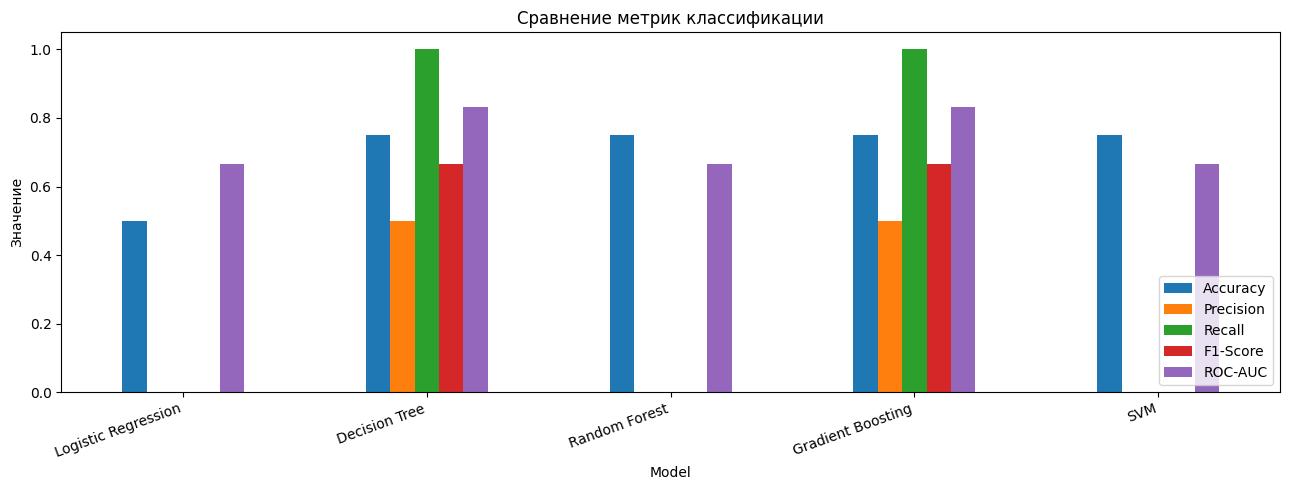

In [70]:
# сравниваем разные методы классификаци
clf_summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree',
              'Random Forest', 'Gradient Boosting', 'SVM'],
    'Accuracy':  [log_acc,  dt_c_acc,  rf_c_acc,  gb_c_acc,  svm_acc],
    'Precision': [log_prec, dt_c_prec, rf_c_prec, gb_c_prec, svm_prec],
    'Recall':    [log_rec,  dt_c_rec,  rf_c_rec,  gb_c_rec,  svm_rec],
    'F1-Score':  [log_f1,   dt_c_f1,   rf_c_f1,   gb_c_f1,   svm_f1],
    'ROC-AUC':   [log_auc,  dt_c_auc,  rf_c_auc,  gb_c_auc,  svm_auc]
}).set_index('Model').round(4)

print("Сводная таблица — Классификация:")
print(clf_summary.to_string())

best_clf = clf_summary['ROC-AUC'].idxmax()
print(f"\nЛучшая модель по ROC-AUC: {best_clf} ({clf_summary.loc[best_clf, 'ROC-AUC']:.4f})")

# График метрик
clf_summary.plot(kind='bar', figsize=(13, 5))
plt.title('Сравнение метрик классификации')
plt.ylabel('Значение')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

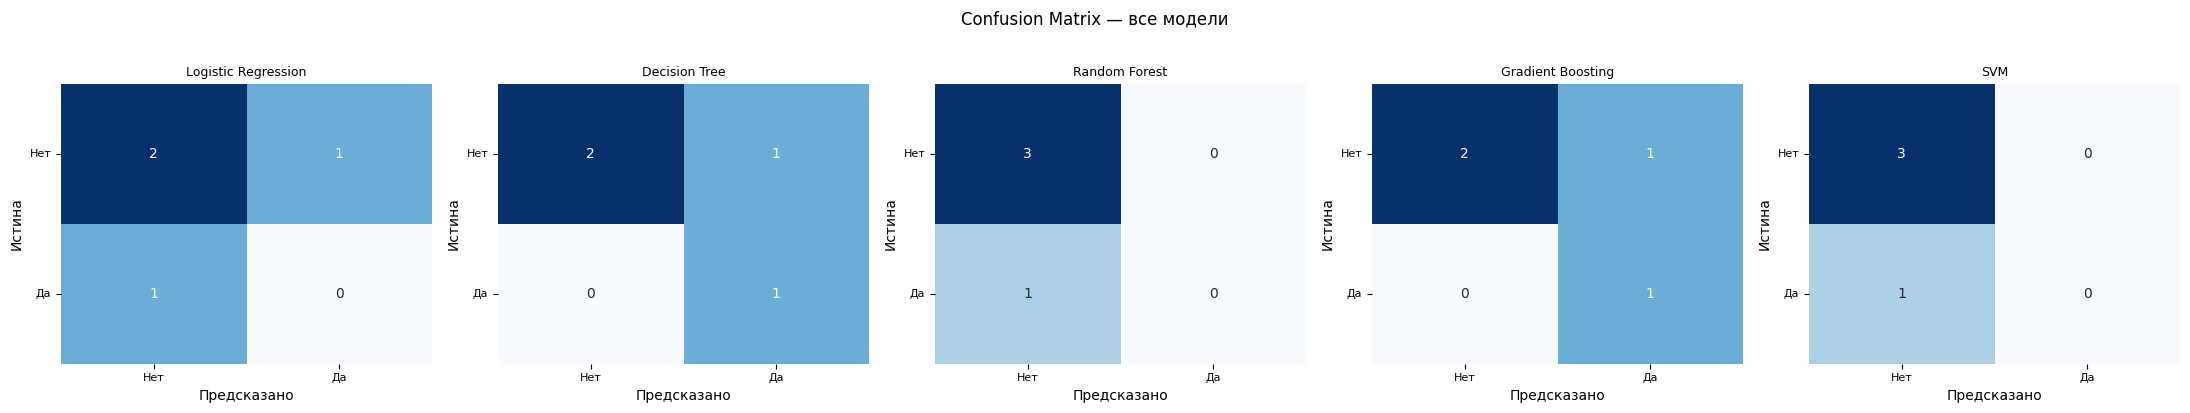

In [71]:
# выводим матрицу ошибок
# матрица ошибок для каждой модели
models_preds = {
    'Logistic Regression': (y_pred_log,  y_proba_log),
    'Decision Tree':       (y_pred_dt_c, y_proba_dt_c),
    'Random Forest':       (y_pred_rf_c, y_proba_rf_c),
    'Gradient Boosting':   (y_pred_gb_c, y_proba_gb_c),
    'SVM':                 (y_pred_svm,  y_proba_svm)
}

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, (y_pred, _)) in zip(axes, models_preds.items()):
    cm = confusion_matrix(y_test_c, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Предсказано')
    ax.set_ylabel('Истина')
    ax.set_xticklabels(['Нет', 'Да'], fontsize=8)
    ax.set_yticklabels(['Нет', 'Да'], fontsize=8, rotation=0)
plt.suptitle('Confusion Matrix — все модели', y=1.02)
plt.tight_layout()
plt.show()

# Case 2: Correlation average TMS response and Medical dataset values
Analyze the correlation between categorical features and the numerical variables 'avg_avg_respone_right' and 'avg_avg_respone_left' in the `tabel_data` DataFrame. This involves converting relevant columns to a numeric data type, identifying categorical features (excluding 'patient_id'), calculating Pearson correlation matrices, and visualizing these correlations using heatmaps. Finally, summarize the key findings from the correlation analysis.

In [ ]:
link_url = 'https://raw.githubusercontent.com/TAUforPython/BioMedAI/refs/heads/main/test_datasets/tms_timeseries_clusters.csv'

table_data_LPRM = pd.read_csv(link_url, sep = ',')
table_data_LPRM = table_data_LPRM.drop('Unnamed: 0',axis=1)
table_data_LPRM.head(5)

,patient_id,Avg_Resp_Left_Mean,Avg_Resp_Left_Std,Avg_Resp_Left_Hurst,Avg_Resp_Right_Mean,Avg_Resp_Right_Std,Avg_Resp_Right_Hurst,Avg_Resp_DTW_Cluster,Avg_Resp_DWT_Cluster,Inh_Thresh_DTW_Cluster,Inh_Thresh_DWT_Cluster,pain_type
0,patient_ 1n,53.259528,12.009135,0.397920,194.736574,40.132561,1.917325,0,1,3,1,2.0
1,patient_ 2n,123.597025,41.771269,1.163941,109.284255,41.218117,1.462129,1,1,1,1,2.0
2,patient_ 3n,39.701583,21.652062,1.099086,84.205208,32.102390,1.186651,3,0,1,1,2.0
3,patient_ 4n,73.540167,23.046395,0.802684,64.819444,13.978575,1.351294,1,0,1,1,2.0
4,patient_ 5n,100.746296,14.629567,0.809085,38.125000,10.383945,0.789748,1,0,1,2,2.0


In [ ]:
merged_df = []
merged_df = pd.merge(table_data_LPRM,
                     all_patients_clustered[['patient_id', 'Score_cluster']],
                     on='patient_id', how='left')

merged_df = pd.merge(merged_df,
                     table_data[subset_dignosis_columns],
                     on='patient_id', how='left')

merged_df = pd.merge(merged_df,
                     table_data[subset_patient_columns].drop('pain_type',axis=1),
                     on='patient_id', how='left')

merged_df = pd.merge(merged_df,
                     table_data[subset_therapy_columns],
                     on='patient_id', how='left')

print("DataFrames merged successfully. First 5 rows of merged_df:")
print(merged_df.head())

DataFrames merged successfully. First 5 rows of merged_df:
    patient_id  Avg_Resp_Left_Mean  Avg_Resp_Left_Std  Avg_Resp_Left_Hurst  \
0  patient_ 1n           53.259528          12.009135             0.397920   
1  patient_ 2n          123.597025          41.771269             1.163941   
2  patient_ 3n           39.701583          21.652062             1.099086   
3  patient_ 4n           73.540167          23.046395             0.802684   
4  patient_ 5n          100.746296          14.629567             0.809085   

   Avg_Resp_Right_Mean  Avg_Resp_Right_Std  Avg_Resp_Right_Hurst  \
0           194.736574           40.132561              1.917325   
1           109.284255           41.218117              1.462129   
2            84.205208           32.102390              1.186651   
3            64.819444           13.978575              1.351294   
4            38.125000           10.383945              0.789748   

   Avg_Resp_DTW_Cluster  Avg_Resp_DWT_Cluster  Inh_Thresh_DTW_C

In [ ]:
merged_df.columns

Index(['patient_id', 'Avg_Resp_Left_Mean', 'Avg_Resp_Left_Std',
       'Avg_Resp_Left_Hurst', 'Avg_Resp_Right_Mean', 'Avg_Resp_Right_Std',
       'Avg_Resp_Right_Hurst', 'Avg_Resp_DTW_Cluster', 'Avg_Resp_DWT_Cluster',
       'Inh_Thresh_DTW_Cluster', 'Inh_Thresh_DWT_Cluster', 'pain_type',
       'Score_cluster', 'restless_legs', 'fatigue', 'fibrimyalgia',
       'tmdibular_pathology', 'migraine', 'bowel_irritable ',
       'chemy_sensitive', 'neck_injuries', 'panic_attack', 'depression', 'sex',
       'age', 'illnes_month', 'nsaid_drug', 'miorelax_drug',
       'antidepress_drug', 'anticonv_drug', 'radio_freq_denerv',
       'exercise_therapy', 'therapy_blockade'],
      dtype='object')

In [ ]:
merged_df = merged_df.dropna(axis=0)
#merged_df = merged_df.fillna(-1)

In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21 entries, 17 to 58
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   patient_id              21 non-null     object 
 1   Avg_Resp_Left_Mean      21 non-null     float64
 2   Avg_Resp_Left_Std       21 non-null     float64
 3   Avg_Resp_Left_Hurst     21 non-null     float64
 4   Avg_Resp_Right_Mean     21 non-null     float64
 5   Avg_Resp_Right_Std      21 non-null     float64
 6   Avg_Resp_Right_Hurst    21 non-null     float64
 7   Avg_Resp_DTW_Cluster    21 non-null     int64  
 8   Avg_Resp_DWT_Cluster    21 non-null     int64  
 9   Inh_Thresh_DTW_Cluster  21 non-null     int64  
 10  Inh_Thresh_DWT_Cluster  21 non-null     int64  
 11  pain_type               21 non-null     float64
 12  Score_cluster           21 non-null     object 
 13  restless_legs           21 non-null     float64
 14  fatigue                 21 non-null     float64


In [ ]:
merged_df = merged_df.drop('tmdibular_pathology', axis=1)

In [ ]:
#merged_df.columns = merged_df.columns.str.strip()

In [ ]:
merged_df['Score_cluster'] = pd.to_numeric(merged_df['Score_cluster'], errors='coerce')
print("'Score_cluster' column converted to numeric type, non-numeric values coerced to NaN.")
print(merged_df[['patient_id', 'Score_cluster']].head())

'Score_cluster' column converted to numeric type, non-numeric values coerced to NaN.
     patient_id  Score_cluster
17   patient_ 1            2.0
20   patient_ 4            NaN
23   patient_ 7            0.0
24   patient_ 8            1.0
35  patient_ 20            1.0


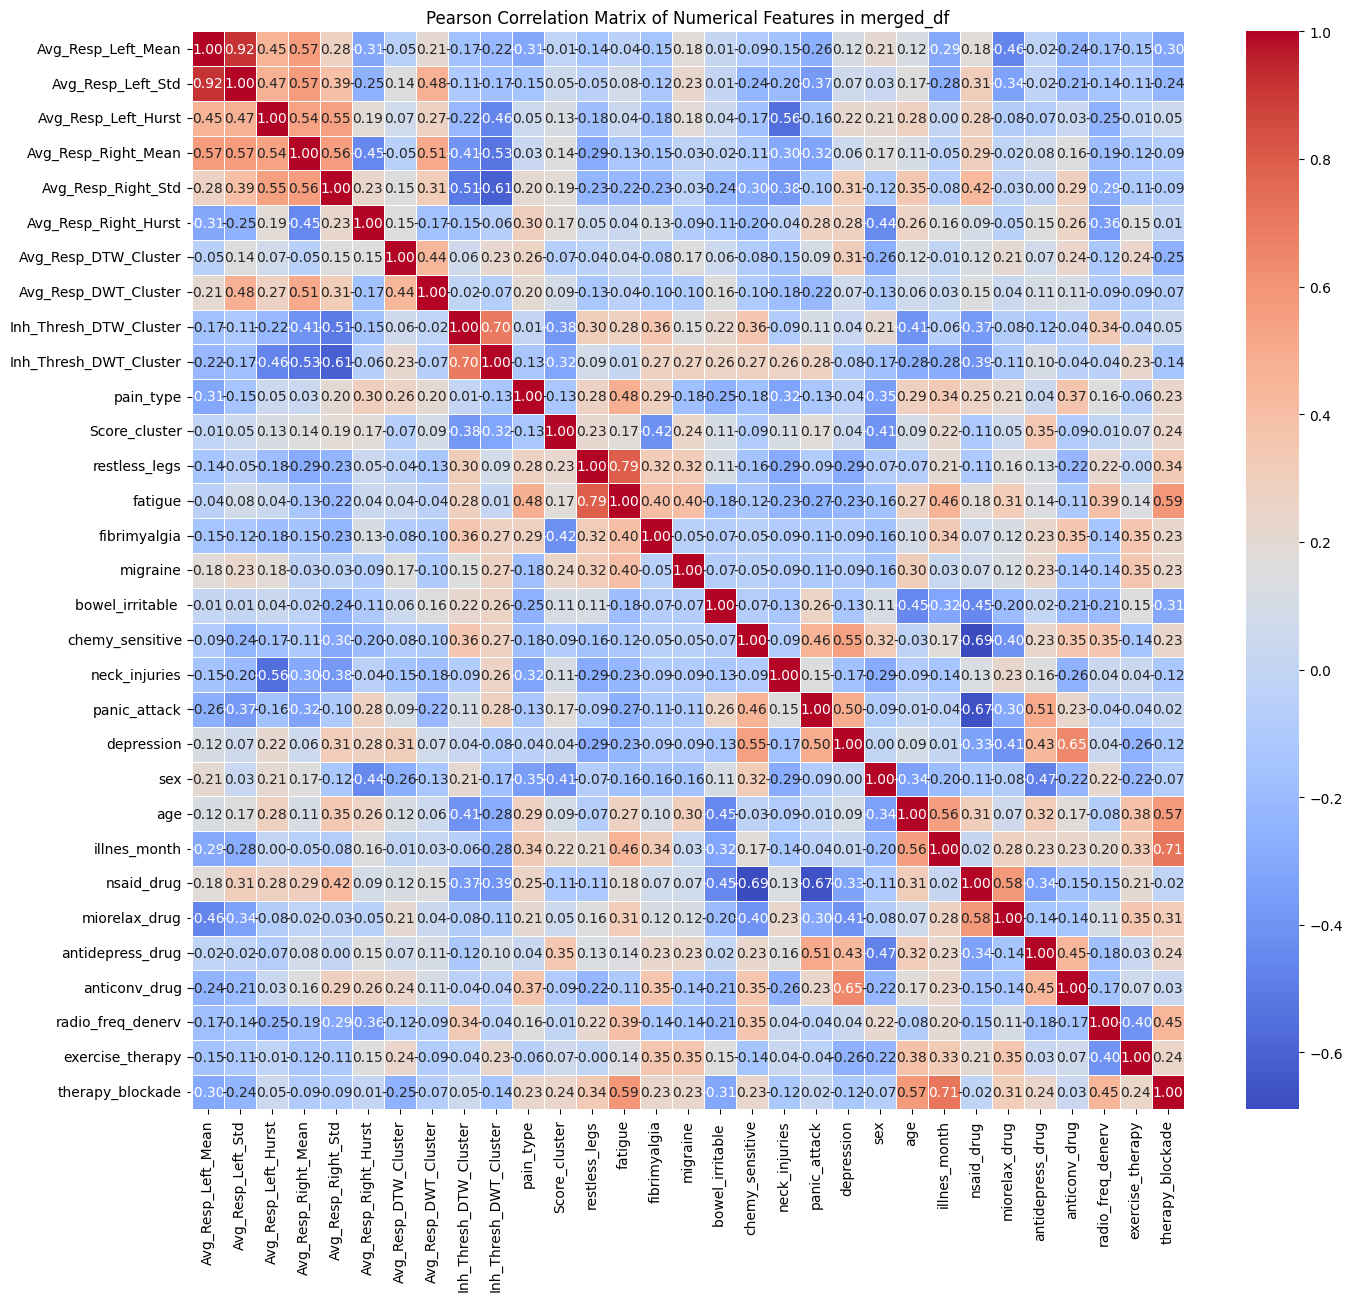

Pearson correlation matrix heatmap generated for numerical features.


In [ ]:
numerical_cols = merged_df.select_dtypes(include=np.number).columns
correlation_matrix = merged_df[numerical_cols].corr(method='pearson')

plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Pearson Correlation Matrix of Numerical Features in merged_df')
plt.show()

print("Pearson correlation matrix heatmap generated for numerical features.")

In [ ]:
merged_df.to_csv('tms_automl_date.csv')

In [ ]:
df_clustering_pca = []
df_clustering_pca = merged_df.copy()
#df_clustering_pca = df_clustering_pca.drop(['patient_id'], axis=1)


for col in df_clustering_pca.columns:
    if df_clustering_pca[col].isnull().any():
        df_clustering_pca[col] = df_clustering_pca[col].fillna(df_clustering_pca[col].mean())

print("df_clustering_pca DataFrame prepared: 'patient_id' columns dropped, missing values imputed with mean.")
print(df_clustering_pca.head())

df_clustering_pca DataFrame prepared: 'patient_id' columns dropped, missing values imputed with mean.
     patient_id  Avg_Resp_Left_Mean  Avg_Resp_Left_Std  Avg_Resp_Left_Hurst  \
17   patient_ 1          178.163333          67.882676             1.257902   
20   patient_ 4           88.539167          29.056679             0.237006   
23   patient_ 7           91.373333          28.543993             1.572665   
24   patient_ 8           97.291667          16.593753             0.885662   
35  patient_ 20          229.881818          58.727715             2.000000   

    Avg_Resp_Right_Mean  Avg_Resp_Right_Std  Avg_Resp_Right_Hurst  \
17           140.767500           27.082901              0.291345   
20            66.661917           16.158868              0.504025   
23            79.481833           24.261729              0.606449   
24            67.640833            6.595104              1.308931   
35           126.798090           27.734369              0.907730   

    Avg_

Use `StandardScaler` to normalize range and Principal Component Analysis (PCA) to reduce the dimensionality of the scaled data, retaining components that cumulatively explain at least 95% of the total variance, to simplify the dataset while preserving most of its information for clustering.



In [ ]:
for col in df_clustering_pca.columns:
    if col != 'patient_id': # Exclude 'patient_id' from conversion
        # Ensure the column is treated as string before replacement to avoid errors on mixed types
        df_clustering_pca[col] = df_clustering_pca[col].astype(str).str.replace(',', '.', regex=False)
        # Convert to numeric, coercing errors to NaN
        df_clustering_pca[col] = pd.to_numeric(df_clustering_pca[col], errors='coerce')

        # Impute missing values with the mean if any NaNs are present after conversion
        #if table_data[col].isnull().any():
        #    table_data[col] = table_data[col].fillna(table_data[col].mean())

print("table_data DataFrame has been cleaned: columns converted to numeric, comma decimals handled, and missing values imputed with the mean.")
print(df_clustering_pca.head())

table_data DataFrame has been cleaned: columns converted to numeric, comma decimals handled, and missing values imputed with the mean.
     patient_id  Avg_Resp_Left_Mean  Avg_Resp_Left_Std  Avg_Resp_Left_Hurst  \
17   patient_ 1          178.163333          67.882676             1.257902   
20   patient_ 4           88.539167          29.056679             0.237006   
23   patient_ 7           91.373333          28.543993             1.572665   
24   patient_ 8           97.291667          16.593753             0.885662   
35  patient_ 20          229.881818          58.727715             2.000000   

    Avg_Resp_Right_Mean  Avg_Resp_Right_Std  Avg_Resp_Right_Hurst  \
17           140.767500           27.082901              0.291345   
20            66.661917           16.158868              0.504025   
23            79.481833           24.261729              0.606449   
24            67.640833            6.595104              1.308931   
35           126.798090           27.734369  

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Scale the data
scaler = StandardScaler()
df_clustering_pca = df_clustering_pca.drop(['patient_id'], axis=1)
df_clustering_pca = df_clustering_pca.fillna(method='ffill')
df_scaled_pca = pd.DataFrame(scaler.fit_transform(df_clustering_pca), columns=df_clustering_pca.columns)
print("Data scaled using StandardScaler.")

# Apply PCA to retain 95% of the variance
pca = PCA(n_components=0.95) # Retain components that explain 95% of the variance
df_pca_reduced = pca.fit_transform(df_scaled_pca)

# Convert to DataFrame for easier inspection, if needed
df_pca_reduced = pd.DataFrame(df_pca_reduced)

print(f"Original number of features: {df_scaled_pca.shape[1]}")
print(f"Reduced number of features after PCA (95% variance retained): {df_pca_reduced.shape[1]}")
print("PCA dimensionality reduction complete. Reduced data head:")
#print(df_pca_reduced.head())

Data scaled using StandardScaler.
Original number of features: 31
Reduced number of features after PCA (95% variance retained): 14
PCA dimensionality reduction complete. Reduced data head:


/tmp/ipython-input-3236260132.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clustering_pca = df_clustering_pca.fillna(method='ffill')


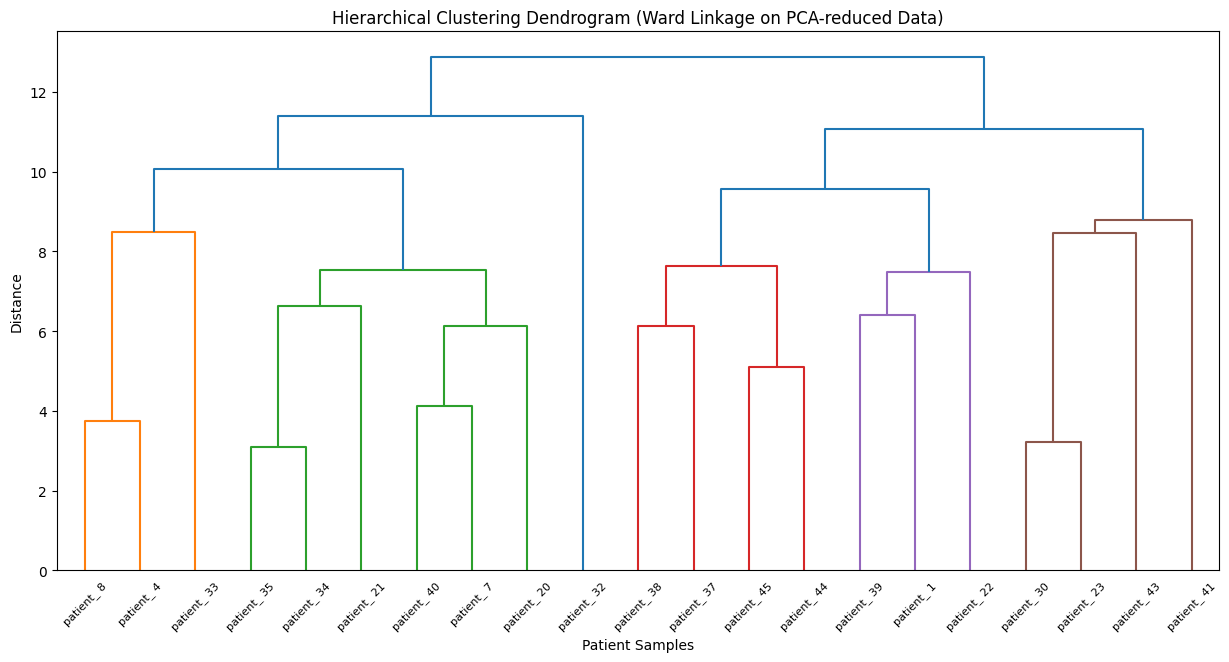

Dendrogram with 'ward' linkage on PCA-reduced data generated.


In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Get patient_ids for labeling the dendrogram
patient_ids_for_dendrogram = merged_df['patient_id'].tolist()

# Generate the linkage matrix using 'ward' method on the PCA-reduced data
linked_ward_pca = linkage(df_pca_reduced, method='ward')

plt.figure(figsize=(15, 7))
dendrogram(linked_ward_pca,
           orientation='top',
           labels=patient_ids_for_dendrogram,
           distance_sort='descending',
           show_leaf_counts=True,
           leaf_font_size=8)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage on PCA-reduced Data)')
plt.xlabel('Patient Samples')
plt.ylabel('Distance')
plt.show()

print("Dendrogram with 'ward' linkage on PCA-reduced data generated.")

# Clustering for score and diagnosis

In [ ]:
table_data.columns

Index(['patient_id', 'sex', 'age', 'pain_type', 'illnes_month',
       'score_pain_reiting', 'score_osvestri', 'score_dn4',
       'score_paint_detect', 'score_beck', 'score_spilberg_person',
       'score_spilberg_anxiety', 'score_pittsburg', 'score_csi',
       'restless_legs', 'fatigue', 'fibrimyalgia', 'tmdibular_pathology',
       'migraine', 'bowel_irritable ', 'chemy_sensitive', 'neck_injuries',
       'panic_attack', 'depression', 'score_mak_gill', 'nsaid_drug',
       'miorelax_drug', 'antidepress_drug', 'anticonv_drug',
       'radio_freq_denerv', 'exercise_therapy', 'therapy_blockade',
       'threshold_left', 'threshold_right', 'motor_evoked_right',
       'motor_evoked_left', 'avg_respone_right', 'avg_respone_left',
       'theshold_edge_right', 'theshold_edge_left',
       'inhibition_threshold_right', 'inhibition_threshold_left',
       'theshold_edge_right.1', 'theshold_edge_left.1',
       'avg_avg_respone_right', 'avg_avg_respone_left',
       'avg_interstimul_thresho

In [ ]:
table_data = table_data.drop('avg_interstimul_threshod', axis=1)

In [ ]:
score_columns = [
       'patient_id','pain_type', 'illnes_month',
       'score_pain_reiting', 'score_osvestri', 'score_dn4',
       'score_paint_detect', 'score_beck', 'score_spilberg_person',
       'score_spilberg_anxiety', 'score_pittsburg', 'score_csi', 'score_mak_gill'
]

In [ ]:
table_data_score = table_data[score_columns]
df_clustering = table_data_score.drop('patient_id', axis=1).copy()

In [ ]:
for col in df_clustering.columns:
    if df_clustering[col].isnull().any():
        df_clustering[col] = df_clustering[col].fillna(df_clustering[col].mean())

print("Missing values handled by mean imputation.")

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_clustering), columns=df_clustering.columns)

#print("Data scaled using StandardScaler.")
#print(df_scaled.head())

Missing values handled by mean imputation.


Use techniques like the Elbow method or Silhouette score to find a suitable number of clusters for the chosen clustering algorithm.


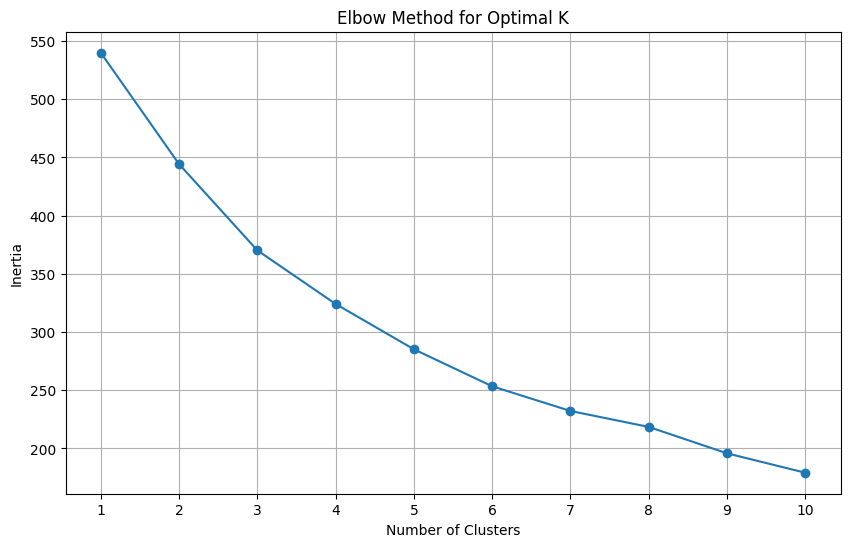

Elbow method plot generated.


In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia_values = []

# Loop through a range of potential cluster numbers
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia_values.append(kmeans.inertia_)

# Plotting the Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia_values, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

print("Elbow method plot generated.")

Based on the Elbow method plot, the optimal number of clusters appears to be **3 or 4**, as this is where the rate of decrease in inertia significantly slows down, forming an 'elbow' shape. Beyond this point, adding more clusters does not significantly improve the model fit.



## Perform clustering
Apply a clustering algorithm (e.g., K-Means) to the prepared data to group patients.


In [ ]:
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

# Fit the KMeans model to the scaled data
kmeans.fit(df_scaled)

# Get cluster labels
cluster_labels = kmeans.labels_

# Add cluster labels to the original tabel_data DataFrame
table_data['cluster'] = cluster_labels

print(f"KMeans clustering performed with {n_clusters} clusters.")
print("First 5 rows of tabel_data with new 'cluster' column:")
print(table_data[['patient_id', 'cluster']].head())

KMeans clustering performed with 3 clusters.
First 5 rows of tabel_data with new 'cluster' column:
   patient_id  cluster
0  patient_ 1        0
1  patient_ 2        1
2  patient_ 3        1
3  patient_ 4        2
4  patient_ 5        1


The scatter plot displays the patient clusters in a 2D space, reduced using Principal Component Analysis (PCA). Each point represents a patient, colored according to their assigned cluster.

**Key Observations from the Visualization:**

*   **Cluster Separation:** The three clusters appear to have some degree of separation, indicating that the K-Means algorithm successfully grouped patients with similar characteristics based on their score and diagnosis features.
*   **Patient Distribution:** Within each cluster, individual patients are labeled with their `patient_id`, `pain_type`, and `illnes_month`. This allows for a granular inspection of the characteristics of patients belonging to specific clusters.
*   **Pain Type and Illness Month:** While a clear pattern is not immediately obvious for `pain_type` and `illnes_month` across all clusters from a high-level view, a closer look at specific clusters might reveal tendencies. For example, some clusters might contain a higher proportion of patients with a particular pain type or a narrower range of illness duration.

**Next Steps for Visualization:**

*   Further analysis could involve calculating the average characteristics of `pain_type` and `illnes_month` (and other original features) for each cluster to quantitatively describe what defines each group. This would provide deeper insights into the clinical relevance of each cluster.

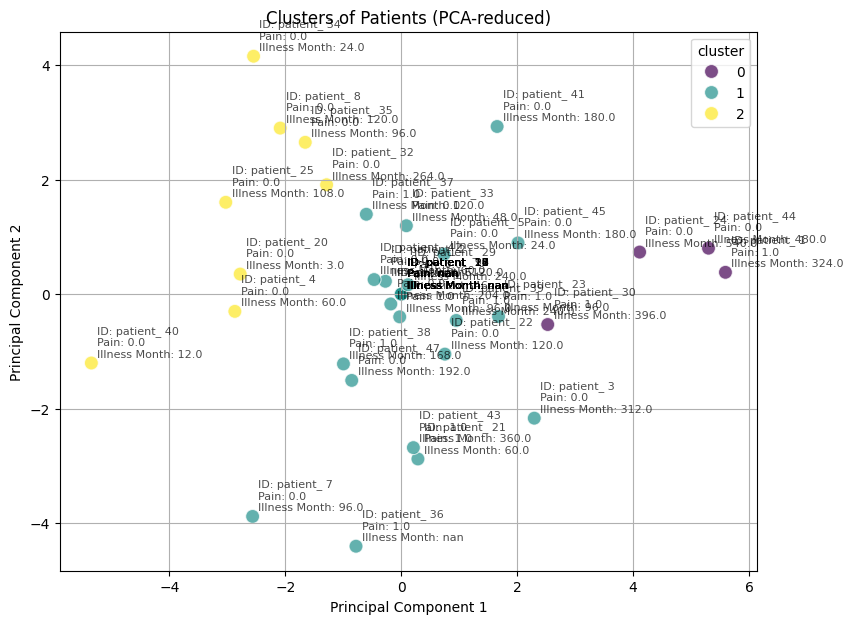

In [ ]:
from sklearn.decomposition import PCA
import seaborn as sns

# Reduce dimensionality for visualization
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(df_pca, columns=['PC1', 'PC2'])

# Add cluster labels and relevant original features back for plotting
df_pca['cluster'] = table_data['cluster']
df_pca['patient_id'] = table_data['patient_id']
df_pca['pain_type'] = table_data['pain_type']
df_pca['illnes_month'] = table_data['illnes_month']

plt.figure(figsize=(9, 7))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='viridis',
    data=df_pca,
    legend='full',
    s=100,
    alpha=0.7
)

# Add labels for patient_id, pain_type, and illnes_month
for i, row in df_pca.iterrows():
    plt.text(row['PC1'] + 0.1, row['PC2'] + 0.1,
             f"ID: {row['patient_id']}\nPain: {row['pain_type']}\nIllness Month: {row['illnes_month']}",
             fontsize=8, alpha=0.7)

plt.title('Clusters of Patients (PCA-reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

## Dendrogram clustering

In [ ]:
df_clustering_pca = table_data.copy()
df_clustering_pca = df_clustering_pca.drop(['patient_id', 'cluster'], axis=1)


for col in df_clustering_pca.columns:
    if df_clustering_pca[col].isnull().any():
        df_clustering_pca[col] = df_clustering_pca[col].fillna(df_clustering_pca[col].mean())

print("df_clustering_pca DataFrame prepared: 'patient_id' and 'cluster' columns dropped, missing values imputed with mean.")
print(df_clustering_pca.head())

df_clustering_pca DataFrame prepared: 'patient_id' and 'cluster' columns dropped, missing values imputed with mean.
   sex  age  pain_type  illnes_month  score_pain_reiting  score_osvestri  \
0    0   72        1.0         324.0            9.000000       58.000000   
1    1   60        0.0         120.0            6.071429       36.071429   
2    0   54        0.0         312.0            7.000000       38.000000   
3    0   25        0.0          60.0            5.000000       22.000000   
4    0   42        0.0          24.0            8.000000       48.000000   

   score_dn4  score_paint_detect  score_beck  score_spilberg_person  ...  \
0   5.000000           24.000000   24.000000                  64.00  ...   
1   3.214286           12.178571   13.153846                  47.75  ...   
2   7.000000           24.000000    9.000000                  45.00  ...   
3   2.000000            7.000000    8.000000                  43.00  ...   
4   3.000000            7.000000   22.000000   

Use `StandardScaler` to normalize range and Principal Component Analysis (PCA) to reduce the dimensionality of the scaled data, retaining components that cumulatively explain at least 95% of the total variance, to simplify the dataset while preserving most of its information for clustering.



In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Scale the data
scaler = StandardScaler()
df_scaled_pca = pd.DataFrame(scaler.fit_transform(df_clustering_pca), columns=df_clustering_pca.columns)
print("Data scaled using StandardScaler.")

# Apply PCA to retain 95% of the variance
pca = PCA(n_components=0.95) # Retain components that explain 95% of the variance
df_pca_reduced = pca.fit_transform(df_scaled_pca)

# Convert to DataFrame for easier inspection, if needed
df_pca_reduced = pd.DataFrame(df_pca_reduced)

print(f"Original number of features: {df_scaled_pca.shape[1]}")
print(f"Reduced number of features after PCA (95% variance retained): {df_pca_reduced.shape[1]}")
print("PCA dimensionality reduction complete. Reduced data head:")
#print(df_pca_reduced.head())

Data scaled using StandardScaler.
Original number of features: 47
Reduced number of features after PCA (95% variance retained): 22
PCA dimensionality reduction complete. Reduced data head:


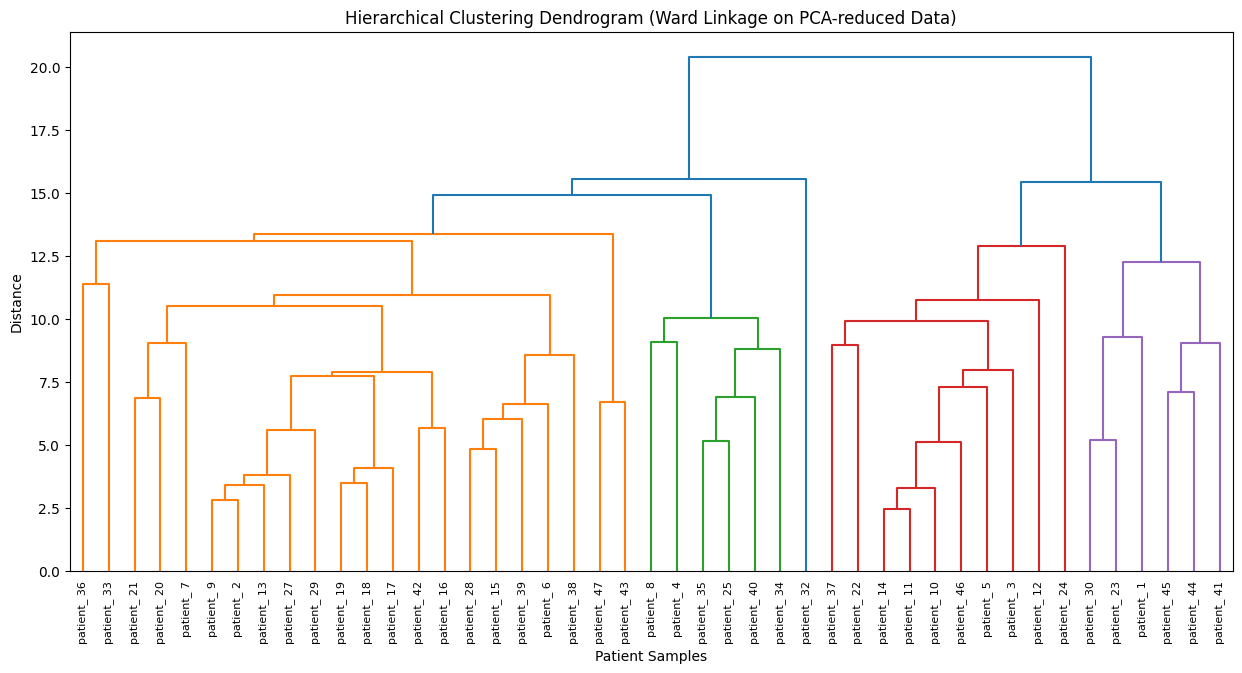

Dendrogram with 'ward' linkage on PCA-reduced data generated.


In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Get patient_ids for labeling the dendrogram
patient_ids_for_dendrogram = table_data['patient_id'].tolist()

# Generate the linkage matrix using 'ward' method on the PCA-reduced data
linked_ward_pca = linkage(df_pca_reduced, method='ward')

plt.figure(figsize=(15, 7))
dendrogram(linked_ward_pca,
           orientation='top',
           labels=patient_ids_for_dendrogram,
           distance_sort='descending',
           show_leaf_counts=True,
           leaf_font_size=8)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage on PCA-reduced Data)')
plt.xlabel('Patient Samples')
plt.ylabel('Distance')
plt.show()

print("Dendrogram with 'ward' linkage on PCA-reduced data generated.")

In [ ]:
table_data.columns

Index(['patient_id', 'sex', 'age', 'pain_type', 'illnes_month',
       'score_pain_reiting', 'score_osvestri', 'score_dn4',
       'score_paint_detect', 'score_beck', 'score_spilberg_person',
       'score_spilberg_anxiety', 'score_pittsburg', 'score_csi',
       'restless_legs', 'fatigue', 'fibrimyalgia', 'tmdibular_pathology',
       'migraine', 'bowel_irritable ', 'chemy_sensitive', 'neck_injuries',
       'panic_attack', 'depression', 'score_mak_gill', 'nsaid_drug',
       'miorelax_drug', 'antidepress_drug', 'anticonv_drug',
       'radio_freq_denerv', 'exercise_therapy', 'therapy_blockade',
       'threshold_left', 'threshold_right', 'motor_evoked_right',
       'motor_evoked_left', 'avg_respone_right', 'avg_respone_left',
       'theshold_edge_right', 'theshold_edge_left',
       'inhibition_threshold_right', 'inhibition_threshold_left',
       'theshold_edge_right.1', 'theshold_edge_left.1',
       'avg_avg_respone_right', 'avg_avg_respone_left',
       'avg_inhibition_threshol

In [ ]:
diagnosis_columns = ['patient_id', 'cluster',
       'restless_legs', 'fatigue', 'fibrimyalgia', 'tmdibular_pathology',
       'migraine', 'bowel_irritable ', 'chemy_sensitive', 'neck_injuries',
       'panic_attack', 'depression','nsaid_drug',
       'miorelax_drug', 'antidepress_drug', 'anticonv_drug',
       'radio_freq_denerv', 'exercise_therapy', 'therapy_blockade'
]

In [ ]:
table_data_diagnosis = table_data[diagnosis_columns]

In [ ]:
# Identify numerical and categorical columns, excluding 'patient_id' and 'cluster'
all_columns = table_data_diagnosis.columns.tolist()
columns_to_exclude = ['patient_id', 'cluster']

features_for_profiling = [col for col in all_columns if col not in columns_to_exclude]

numerical_features = table_data[features_for_profiling].select_dtypes(include=np.number).columns.tolist()
categorical_features = table_data[features_for_profiling].select_dtypes(include='object').columns.tolist()

# Handle the special case of 'sex' if it's considered categorical but is numeric (0/1)
# We'll treat 0/1 columns as categorical if they are not already in categorical_features list
for col in numerical_features:
    unique_vals = table_data[col].dropna().unique()
    if len(unique_vals) <= 5 and all(val in [0, 1] for val in unique_vals):
        categorical_features.append(col)
        numerical_features.remove(col)


# Group by cluster and calculate mean for numerical features
numerical_cluster_profile = table_data.groupby('cluster')[numerical_features].mean()
#print("\nNumerical Feature Profile per Cluster (Mean):")
#print(numerical_cluster_profile)

# For categorical features, count occurrences within each cluster
#print("\nCategorical Feature Profile per Cluster (Value Counts/Proportions):")
for col in categorical_features:
#    print(f"\n--- {col} ---")
    counts = table_data.groupby('cluster')[col].value_counts(normalize=True).unstack(fill_value=0)
#    print(counts)


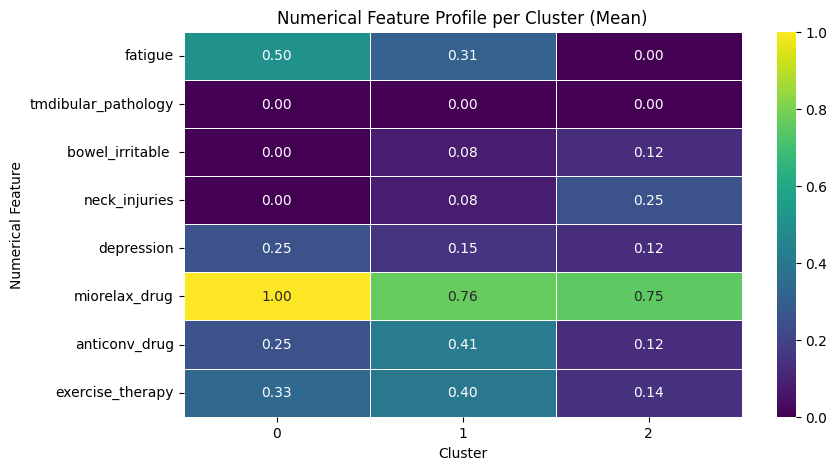

In [ ]:
plt.figure(figsize=(9, 5))
sns.heatmap(numerical_cluster_profile.T, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Numerical Feature Profile per Cluster (Mean)')
plt.xlabel('Cluster')
plt.ylabel('Numerical Feature')
plt.show()

### Visualize Clusters with a Dendrogram
Dendrogram method calculates the average distance between all pairs of observations in two clusters before merging them. This can sometimes produce more balanced dendrograms and offer a different perspective on cluster formation compared to the 'ward' method, which minimizes the variance within each cluster.


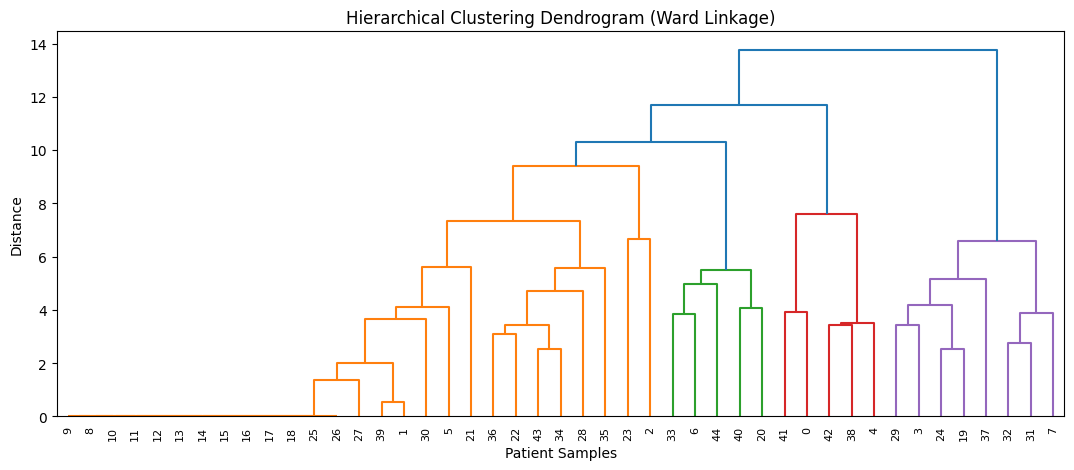

Dendrogram with 'average' linkage generated.


In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Generate the linkage matrix using 'average' method
linked_average = linkage(df_scaled, method='ward')

plt.figure(figsize=(13, 5))
dendrogram(linked_average,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True,
           leaf_font_size=8)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Patient Samples')
plt.ylabel('Distance')
plt.show()

print("Dendrogram with 'average' linkage generated.")

# Check statistical significance

In [ ]:
link_url = 'https://raw.githubusercontent.com/TAUforPython/BioMedAI/refs/heads/main/test_datasets/tms_timeseries_clusters.csv'

df = pd.read_csv(link_url, sep = ',')
df = df.drop('Unnamed: 0', axis=1)
df.head(5)


,patient_id,Avg_Resp_Left_Mean,Avg_Resp_Left_Std,Avg_Resp_Left_Hurst,Avg_Resp_Right_Mean,Avg_Resp_Right_Std,Avg_Resp_Right_Hurst,Avg_Resp_DTW_Cluster,Avg_Resp_DWT_Cluster,Inh_Thresh_DTW_Cluster,Inh_Thresh_DWT_Cluster,pain_type
0,patient_ 1n,53.259528,12.009135,0.397920,194.736574,40.132561,1.917325,0,1,3,1,2.0
1,patient_ 2n,123.597025,41.771269,1.163941,109.284255,41.218117,1.462129,1,1,1,1,2.0
2,patient_ 3n,39.701583,21.652062,1.099086,84.205208,32.102390,1.186651,3,0,1,1,2.0
3,patient_ 4n,73.540167,23.046395,0.802684,64.819444,13.978575,1.351294,1,0,1,1,2.0
4,patient_ 5n,100.746296,14.629567,0.809085,38.125000,10.383945,0.789748,1,0,1,2,2.0


In [ ]:
from scipy.stats import kruskal

=== Тест для комбинации Hurst + Mean + Std ===
Название признака: combined_HMS_score
Формула: asym(H) + asym(M) + asym(S)
Kruskal–Wallis H = 8.2451, p = 0.01620
✅ СТАТИСТИЧЕСКИ ЗНАЧИМО (p < 0.05)


/tmp/ipython-input-3664111940.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='pain_type', y='combined_HMS_score', palette='Set2')


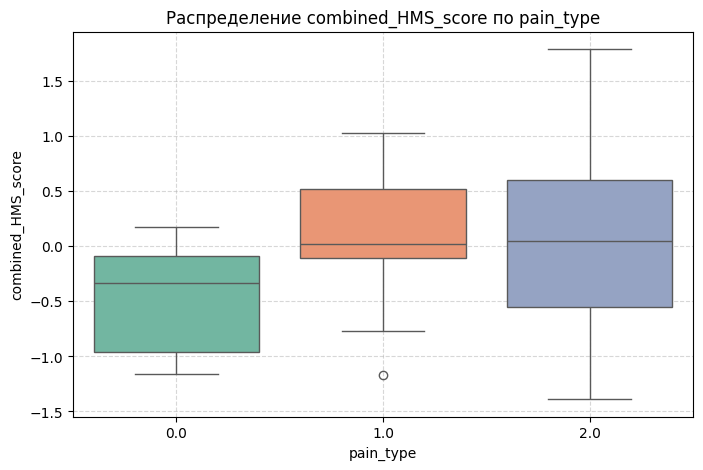


=== Медианы по группам ===
pain_type = 0: медиана = -0.3331
pain_type = 1: медиана = 0.0185
pain_type = 2: медиана = 0.0454


In [ ]:

# Удалим строки с пропусками
df = df.dropna(subset=[
    'Avg_Resp_Left_Mean', 'Avg_Resp_Left_Std', 'Avg_Resp_Left_Hurst',
    'Avg_Resp_Right_Mean', 'Avg_Resp_Right_Std', 'Avg_Resp_Right_Hurst',
    'pain_type'
])

# Обозначения
L_M = df['Avg_Resp_Left_Mean']
L_S = df['Avg_Resp_Left_Std']
L_H = df['Avg_Resp_Left_Hurst']

R_M = df['Avg_Resp_Right_Mean']
R_S = df['Avg_Resp_Right_Std']
R_H = df['Avg_Resp_Right_Hurst']

eps = 0

# Новая комбинация: нормированная асимметрия по H, M, S
asym_H = (R_H - L_H) / (R_H + L_H + eps)
asym_M = (R_M - L_M) / (R_M + L_M + eps)
asym_S = (R_S - L_S) / (R_S + L_S + eps)

df['combined_HMS_score'] = asym_H + asym_M + asym_S

# Kruskal–Wallis test
groups = [df[df['pain_type'] == pt]['combined_HMS_score'] for pt in sorted(df['pain_type'].unique())]
H_stat, p_val = kruskal(*groups)

print("=== Тест для комбинации Hurst + Mean + Std ===")
print(f"Название признака: combined_HMS_score")
print(f"Формула: asym(H) + asym(M) + asym(S)")
print(f"Kruskal–Wallis H = {H_stat:.4f}, p = {p_val:.5f}")

if p_val < 0.05:
    print("✅ СТАТИСТИЧЕСКИ ЗНАЧИМО (p < 0.05)")
else:
    print("❌ Не значимо")

# Визуализация
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='pain_type', y='combined_HMS_score', palette='Set2')
plt.title('Распределение combined_HMS_score по pain_type')
plt.xlabel('pain_type')
plt.ylabel('combined_HMS_score')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Описательная статистика
print("\n=== Медианы по группам ===")
for pt in sorted(df['pain_type'].unique()):
    median_val = df[df['pain_type'] == pt]['combined_HMS_score'].median()
    print(f"pain_type = {int(pt)}: медиана = {median_val:.4f}")

`combined_HMS_score` объединяет **нормированную межполушарную асимметрию** по трём ключевым характеристикам TMS-ответа:

\[
\text{asym}_X = \frac{X_R - X_L}{X_R + X_L}, \quad X \in \{ \text{Hurst},\ \text{Mean},\ \text{Std} \}
\]

Это — **относительная разность**, выражающая, **насколько одно полушарие отличается от другого в процентах от их общей активности/сложности**.

---

#### 1. **Инвариантность к индивидуальному масштабу**
- У разных пациентов **абсолютные значения** (например, амплитуда ответа) сильно различаются из-за:
  - возраста,
  - толщины черепа,
  - положения катушки,
  - уровня возбудимости коры.
- Использование **относительной разности** устраняет этот источник вариабельности.
- Пример:  
  - Пациент A: `R_M = 200`, `L_M = 100` → `asym_M = (200−100)/(200+100) = 0.33`  
  - Пациент B: `R_M = 40`, `L_M = 20` → `asym_M = (40−20)/(40+20) = 0.33`  
  → **одинаковая относительная асимметрия**, несмотря на разный масштаб.

> Это критически важно для **сравнения между пациентами**.

#### 2. **Интеграция трёх независимых аспектов TMS-ответа**
- **Hurst exponent** — отражает **сложность и долгосрочную зависимость** нейронального ответа (связан с саморегуляцией, стабильностью сети).
- **Mean (амплитуда)** — мера **силы коркового ответа** (возбудимость).
- **Std (стандартное отклонение)** — показатель **вариабельности/стабильности** ответа от стимула к стимулу.
- Комбинирование этих трёх аспектов даёт **целостную картину межполушарного дисбаланса**, а не фокусируется на одном признаке.

#### 3. **Физиологическая интерпретация знака**
- Положительное значение `asym_X` → **правое полушарие выше** по параметру `X`.
- Отрицательное → **левое выше**.
- Сумма `asym_H + asym_M + asym_S` усиливает сигнал, если **асимметрия согласована по нескольким параметрам** (например, правое полушарие и сложнее, и сильнее, и стабильнее).
- Это повышает **чувствительность к патологическим паттернам**, характерным для хронической боли.

#### 4. **Совместимость с нейрофизиологическими моделями**
- В литературе по TMS и хронической боли часто описывают **гиперактивность одного полушария** и **гипоактивность другого** — причём это касается **и амплитуды, и вариабельности, и динамики**.
- Ваш признак **естественным образом ловит такой синхронный дисбаланс**.

---
Признак `combined_HMS_score`:

- **Физиологически мотивирован**: отражает согласованную межполушарную асимметрию по трём ключевым параметрам.
- **Статистически робастен**: инвариантен к масштабу, усиливает согласованный сигнал.
- **Клинически интерпретируем**: положительные/отрицательные значения указывают на доминирование правого/левого полушария.
- **Позволяет выявить скрытые различия** между группами `pain_type`, даже если отдельные признаки не значимы.

Если тест **показал p < 0.05**, вы нашли **интегративный биомаркер**, который может быть использован для **дифференциальной диагностики типов боли** на основе TMS-ответов.